In [94]:
#arranque
using LaTeXStrings
using DoubleFloats
using Latexify
using ImageInTerminal
using Plots
using DataFrames
using CSV
using Measures

#graficación
theme(:ggplot2)

default(size = (900,600), guidefontsize=14, tickfontsize=14, legendfontsize = 16,
left_margin = 20mm, bottom_margin = 20mm)

#constantes
h = Double64(6.62607015E-34)
c = Double64(299792458)
eV = Double64(1.602177E-19)
b = Double64(0.0028796)
ħ = h/(2π)  #constante de Planck/2π
e = Double64(1.602176634E-19)  #carga del electrón SI
me = Double64(9.1093837015E-31) #masa del electrón en kg
mp =  Double64(1.67262192369E-27) #masa del protón en kg
kc = Double64(8.9875517873681764E9)	#constante de Coulomb
ke = kc
k = Double64(1.380649*10^(-23))
σ = (2 * π^5 * k^4) / (15 * h^3 * c^2);

# Mecánica Cuántica

#### Algún *racconto*

1. ***El problema original***: la energía de ondas de campo electromagnético, según algunos experimentos:
   * Estaba cuantizada según su frecuencia: $E = nhf \; p = h/\lambda \quad n = 0,1,2,3,...$


   * Se transmitía en paquetes enteros, lo que llevó a que las ondas EM se interpretaran, a la vez, como ondas y partículas (principio de complementariedad).
  
   * Las expresiones para la energía y el momento del campo EM y pasaron a tener correlatos **cuantizados**.

#### Algún *racconto*

2. ***De Broglie***: propone que lo que conocemos como partículas **también** son ondas.
   * $E = hf$ ; $p = h/\lambda$
   * Sin embargo, no hay **campo de materia** (en el sentido de que algo oscilara), y el primer problema que resolvimos es el de obtener algún correlato oscilatorio de **localización** de partículas usando ***paquetes de onda*** (muchas $\lambda 's$ juntas dan localización, pero define el momento como una distribución de momentos.
   * Esto nos llevó a visitar el ***principio de incertidumbre***: $\sigma_p \sigma_x \geq \hbar/2$

#### Previa: ¿cómo hacemos para pensar una función de onda para partículas?
**Fotones**

* Si hay $N$ fotones en un volumen $V$, entonces la probabilidad de encontrar un fotón en ese volumen es:

$$\frac{Probabilidad}{V} \propto \frac{N}{V} $$

* El número de fotonoes $N$ por unidad de volumen $V$ es proporcional a la intensidad de la radiación:
  $$ \frac{N}{V} \propto I \propto E^2 \Longrightarrow \frac{Probabilidad}{V} \propto E^2$$

La probabilidad de encontrar un fotón por unidad de volumen es proporcional al cuadrado del campo eléctrico, $E^2$.

##### ¿Qué oscila?: función de onda e interpretación de Born
Nadie sabe mucho qué es lo que oscila. Sin embargo, a las funciones de onda asociadas a una partícula, $\Psi (x,y,z,t)$ les caben algunas propiedades:

* Probabilidad de encontrar una partícula (Born , 1928).
$$ \int \Psi^*(x, y, z, t)  \Psi((x, y, z, t)) dV=\int _a ^b |\Psi(x)^2| dx= P(t)$$

#### Funciones de onda unidimensionales y valores permitidos
* El cuadrado de la función de onda es la **densidad de probabilidad** de la posición de la partícula.
 $$P dx = |\Psi(x)|^2 \,dx \quad \text{en realidad $\Psi$ es compleja, así es que } (\Psi^*(x) \; \Psi(x))$$

* Como toda densidad de probabilidad: $$\int_{-\infty}^\infty|\Psi|^2 \; dx = 1$$

* Se puede conocer el valor medio de $f(x)$, $\big< f(x)\big>$, a partir de: $$\big< f(x)\big> = \int_{-\infty}^\infty \Psi^* (x) \, f(x) \Psi(x) \; dx \quad si \; \Psi \in \mathcal{R} \longrightarrow \big< f(x)\big> = \int_{-\infty}^\infty f(x) |\Psi(x)|^2 \; dx$$

#### Ejemplo:  Una función de onda para una partícula
Tenemos que una partícula cuántica está descrita por: $$\Psi(x) = A \, e^{-ax^2}$$
**(a)** Encuentre el valor de $A$.

**(b)** Encuentre el valor medio $\big< x \big>$

In [2]:
a = 1.0;
x = -3.5:0.01:3.5
Ψ = exp.(-a .* x .^2);

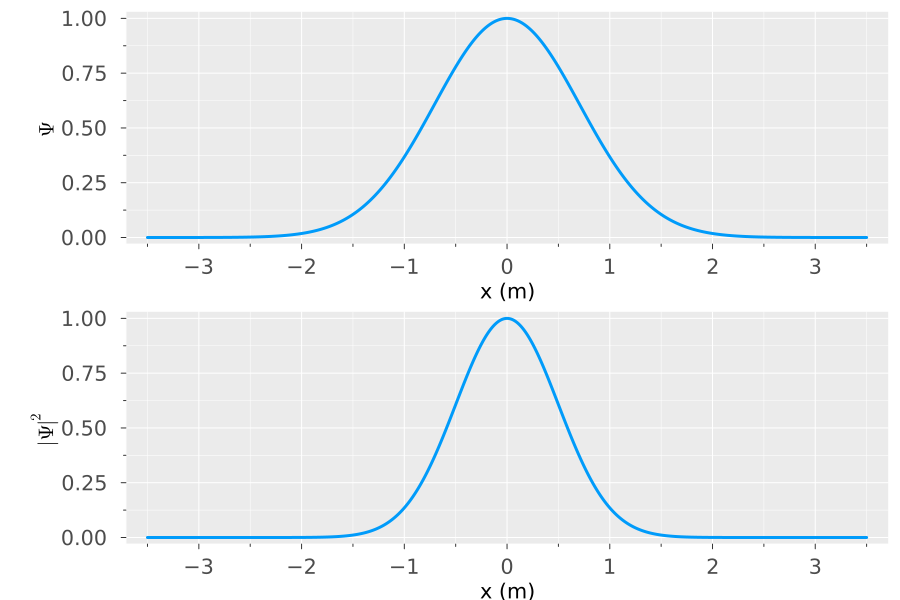

In [3]:
gsi = plot(x, Ψ, xlabel = "x (m)", ylabel = L"\Psi", label = false, linewidth = 3)
gsicuad = plot(x, Ψ .^2, xlabel = "x (m)", ylabel = L"|\Psi|^2", label = false, linewidth = 3);
plot(gsi,gsicuad, layout = (2,1))

Tenemos que ***normalizar*** $\Psi$, con lo que:
$$\int_{-\infty}^\infty |\Psi(x)|^2 \; dx = \int_{-\infty}^\infty A^2 \; e^{-2ax^2} \; dx = 1$$

De aquí, hacemos:
$$A^2 = \frac{1}{\int_{-\infty}^\infty \; e^{-2ax^2} \; dx} = \frac{1}{\sqrt{\frac{\pi}{2a}}} \Longrightarrow A = \Bigg( \frac{2a}{\pi}\Bigg)^{1/4}$$

**(b)** Podemos calcular el valor medio de la posición, $<x>$ como:

$$
\big< x \big> = \int_{-\infty}^{\infty}x \; \big|\psi(x)\big| \; dx = \int_{-\infty}^{\infty} x \; \Bigg( \frac{2a}{\pi}\Bigg)^{1/2} e^{-2ax^2} \; dx \Longrightarrow
$$

$$
\big< x \big> = \Bigg( \frac{2a}{\pi}\Bigg)^{1/2} \int _{-\infty}^{\infty} x \; e^{-2ax^2} \; dx
$$

Si bien se puede calcular esta integral, lo piola es que, al ver la función, podemos predecir que:

$f(x) = -f(-x)$, es decir, $f(x)$ es una función impar, ergo, al integrarla entre $(-\infty, \infty)$, tenemos que la integral da $0$.

In [4]:
ψx = x .* exp.(-2a .* x .^2);

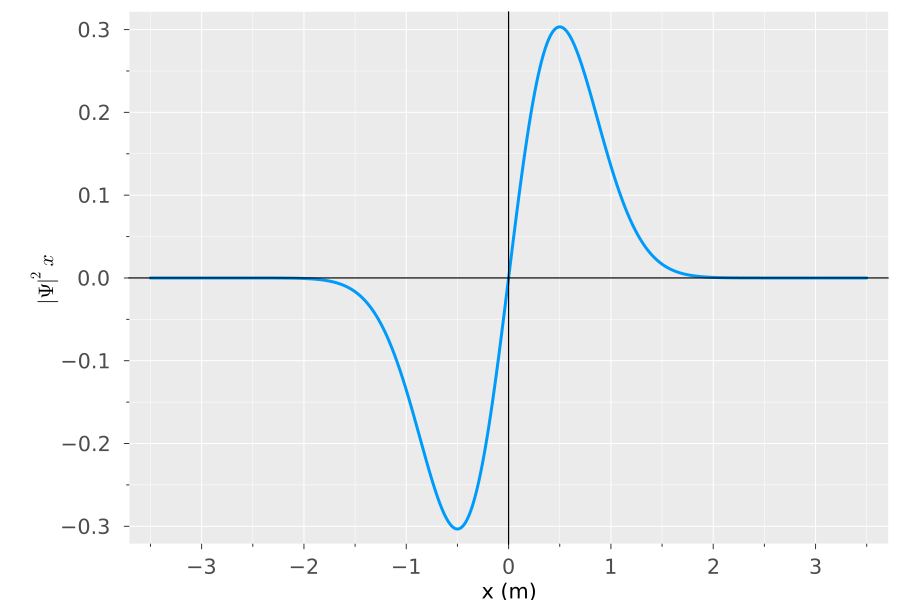

In [12]:
plot(x, ψx, xlabel = "x (m)", ylabel = L"|\Psi|^2 \;x", label = false, linewidth = 3)
hline!([0], linewidth = 1.2, label = false, color = :black)
vline!([0], linewidth = 1.2, label = false, color = :black)

#### Partícula en una caja

La partícula en una caja es un ejemplo no sólo bobo, sino estrictamente *irrealizable*: supone una caja cuyas paredes están representadas por escalones de energía potencial infinitamente grandes (lo cual, en el sentido estricto, es imposible). A pesar de su irrealidad, nos permite pensar algunas cosas de manera simple.
|||
|:---:|:---|
|<img src="./grafdat/PCuno.png" width="1000px"/>| Tenemos una caja **unidimensional** de largo $L$, conteniendo una partícula cuántica de masa $m$ </br></br> $\bullet$ El comportamiento dinámico de la partícula es "*ir, rebotar y venir con la misma rapidez* **u**". Como la rapidez es la misma, tenemos una longitud de onda definida: $$p = mu = \frac{h}{\lambda}$$clásicamente la partícula en una caja puede tener cualquier rapidez.  </br></br> $\bullet$ Como el pozo de potencial es infinito, la función de onda $\psi$ ***debe ser cero*** en cualquier lugar $L < x < 0$ (fuera de la caja), siendo cero la probabilidad de encontrar a la partícula aquí. </br> $\bullet$ Por lo anterior, tendremos que: $$\int_{-\infty}^\infty |\psi(x)|^2 \; dx = \int_{0}^L |\psi(x)|^2 \; dx = 1$$|

|||
|:---:|:---|
|<img src="./grafdat/PCpsi.png" width="1000px"/>|$\bullet$ Además, la función de onda debe ser continua dentro del intervalo $0 < x < L$, esto es, no puede haber saltos discretos. Dado que la función de onda es cero fuera de la caja, necesariamente tendremos que debe ser cero *en* los extremos de la caja: $$\psi(x = 0) = \psi(x = L) = 0$$ </br> $\bullet$ Proponemos una función de onda con longitud de onda bien definida, como $$\psi(x) = A sen(2\pi x / \lambda)$$. Provisoriamente, podemos pensar que proponemos esta función porque tiene rapidez definida, via $p = mu = h/\lambda$.|

**Condiciones de contorno de la partícula en una caja**

* En el extremo $x = 0$ tenemos: $$\psi (0) = A sen\Big(\frac{2\pi 0}{\lambda}\Big) = A sen\Big(0\Big) = 0$$ esta condición se mantiene para cualquier $\lambda > 0$.

* Para el extremo *derecho*, $x = L$, tenemos que:

 $$\psi (L) = A sen\Big(\frac{2\pi L}{\lambda}\Big) = 0$$

con lo que la función $sen(2\pi L / \lambda)$ será cero si el argumento del seno es: $$2\pi L / \lambda = n\pi \quad con \; n = 1,2,3,...\Longrightarrow$$ $$\Longrightarrow \boxed{\lambda_n = \frac{2L}{n}}$$

Esto parece tonto, pero, por las condiciones de contorno:
* La longitud de onda está **cuantizada**:

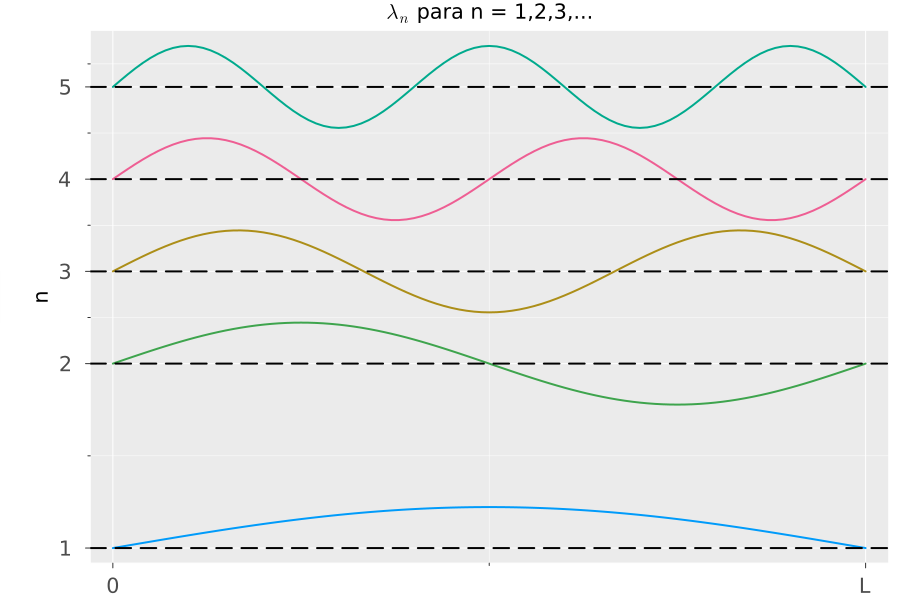

In [60]:
n = 1:1:10
λ = 2 ./ n;
x = 0:0.01:1
ψ1 = sin.( (2*π / λ[1]) .*x)

g = plot(x, ψ1, label = "n = 1",ylabel = "n", linewidth = 2, legend = (-0.2, 0.5), title = L"$λ_n$ para n = 1,2,3,...",
    xticks = ([0,1],["0","L"]), yticks = (2.25 .* [0,2,3,4,5], ["1","2","3","4","5"]) );

hline!([0], style = :d,color = :black, linewidth = 2, label = false);
for i ∈ 2:5
    plot!(x, 2.25 * Float64(i) .+ sin.( (2*π / λ[i]) .*x), label = false, linewidth = 2,
         ) ;
    hline!([2.25*i], style = :d,color = :black, linewidth = 2, label = false);

end 
plot(g)

* Siguiendo a De Broglie, el momento está cuantizado:

$$p_n = \frac{h}{\lambda} = \frac{hn}{2L}$$

* La rapidez estará cuantizada como: $u = \frac{hn}{2Lm}$, donde $m$ es la masa de la partícula.

* La energía
$$E = U + K = 0 + K = \frac{p^2}{2m} = \frac{h^2 n^2}{8 m L^2}$$

está cuantizada con **número cuántico** $n = 1,2,3,...$.

Un rasgo distintivo de la MCuántica: 
* Todas las partículas confinadas tienen niveles de energía discretos
  
* El menor nivel de energía $n=1$ no es cero.


## La ecuación de Schrödinger

De Broglie:

* Resolvemos con una longitud de onda definida.
* Para esto tenemos que $U = cte$

**¿Qué pasa si $U \equiv U(x)$?** No podemos decir mucho.

## La ecuación de Schrödinger
|||
|:---:|:---|
|<img src="./grafdat/MCs.jpg" width="300px"/>|$\bullet$ Erwin Schrödinger (1887-1961) </br></br></br></br> $\bullet$ Desarrolló una ecuación (la ec. de él mismo) </br></br></br></br> $\bullet$ Esta ecuación nos permite trabajar con potenciales arbitrarios (como el de un átomo)</br></br></br></br> $\bullet$ La solución entrega $\psi(x,t)$ que es la función de onda de una partícula.|


## La Ecuación de Schrödinger

La versión general es:

$$-\frac{\hbar^2}{2m} \nabla^2 \Psi(r,t) + U(r,t) \Psi(r,t) =i\hbar \frac{\partial}{\partial t}\psi(r,t)$$

La que miramos será la independiente del tiempo, en una dimensión:

$$\boxed{-\frac{\hbar^2}{2m} \frac{d^2 \psi}{dx^2}+ U(x) \psi = E \psi}$$

* $\psi(x)$ es la función de onda que describe la partícula (mantenemos $P = \psi^*\; \psi = |\psi|^2$)
* $U(x)$ es la energía potencial del sistema.
* $E = U + K$ es la energía total del sistema.

### Partícula en una caja versión Schrödinger
|||
|:---:|:---|
|<img src="./grafdat/PCuno.png" width="300px"/>|La energía potencial dentro de la caja es $U = 0$: $$-\frac{\hbar^2}{2m} \frac{d^2 \psi}{dx^2}+ 0 \psi = E \psi$$ Tenemos entonces: $$ \frac{d^2 \psi}{dx^2}= -\frac{2mE}{\hbar^2} \psi = -k^2 \psi$$ Esta ecuación diferencial tiene por solución: $$\psi(x) = A \;sen(kx) + B\; cos (kx)$$ Aplicando condiciones de contorno: $$\psi = A\; sen(2\pi x/\lambda_n) \quad con \quad \lambda_n = \frac{2L}{n}\quad n=1,2,3,...$$|

## Partícula en una caja endeble (potenciales finitos).

Se puede resolver, pero implica resolver para tres regiones de energía potencial discontinua y ***empalmar*** las soluciones, v.g., $\psi_1(x = L) = \psi_2 (x = L)$ y $d\psi_1/dx (x = L) = d\psi_2/dx (x= L)$, lo cual es engorroso.

Los niveles de energía quedan parecidos, pero el rasgo distintivo...
<img src="./grafdat/PCf.png" width="800px"/>

es que la partícula tiene probabilidad finita de estar en regiones clásicamente prohibidas (I y III en la figura).

## Volviendo sobre el átomo de Hidrógeno (es tedioso pero necesario).

El modelo de Bohr cuantiza el momento angular $L = mvr = n\hbar$, y se obtienen energías cuantizadas:
$$E_n = -\frac{13.6 eV}{n^2}$$

Este modelo fue un *jitazo, gitazo hitazo*, pero violaba varias reglas conocidas del EM, y no explicaba otro montón de cosas.

### Átomo de Hidrógeno: revisita Schrödinger.

Sabemos que el pontecial coulombiano del par electrón-protón es:
$$U(r) = - k_e\frac{e^2}{r}$$
donde $k_e$ es la constante de Coulomb, $e$ es la carga fundamental y $r$ es la distancia entre el protón y el electrón.

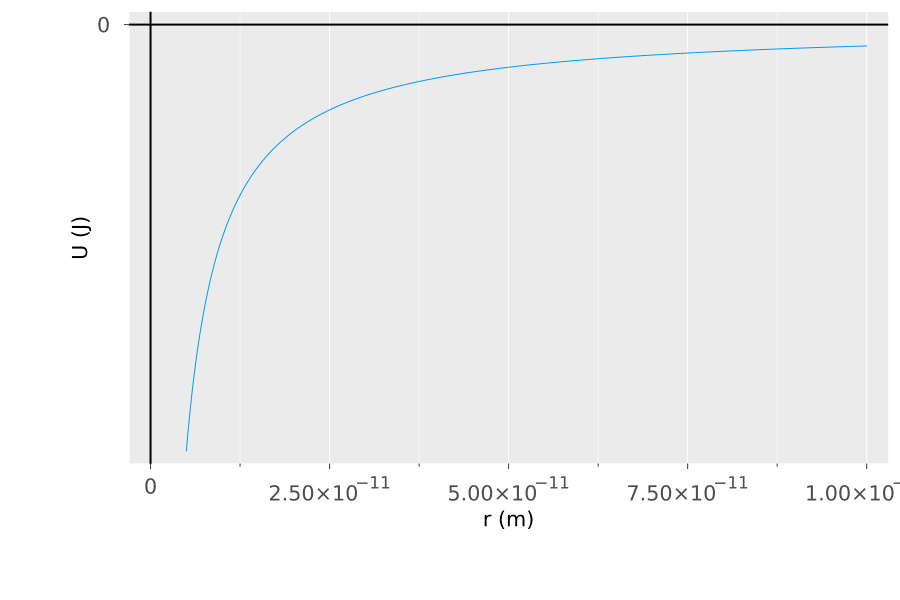

In [93]:
r = 0.5E-11:1E-14:1E-10
U = -kc * e^2 ./r
plot(r,U, label = false, ylabel = "U (J)", xlabel = "r (m)", yticks = [0])
hline!([0], linewidth = 2, color = :black, label = false)
vline!([0], linewidth = 2, color = :black, label = false)

#### Átomo de Hidrógeno: revisita Schrödinger.

El chiste que hace difícil la solución es que está en 3D:

$$-\frac{\hbar^2}{2m}\Big(\dfrac{\partial^2 \psi}{\partial x^2} + \dfrac{\partial^2 \psi}{\partial y^2} + \dfrac{\partial^2 \psi}{\partial z^2} \Big) + U \psi = E\psi \overbrace{\Longrightarrow}^{\text{reemplazando U}}$$

$$-\frac{\hbar^2}{2m}\Big(\dfrac{\partial^2 \psi}{\partial x^2} + \dfrac{\partial^2 \psi}{\partial y^2} + \dfrac{\partial^2 \psi}{\partial z^2} \Big) - k_e\frac{e^2}{r} \psi = E\psi $$

El problema es que hay que reescribir nabla cuadrado a coordenadas esféricas...así es que chau cuentas formales. Lo que si vemos es que $U$ sólo depende de $r$, por lo que proponemos:

$$\psi (r,\theta,\phi) = R(r)f(\theta)g(\phi)$$

#### Átomo de Hidrógeno: revisita Schrödinger.

De aquí se sacan 3 ecs. diferenciales separadas para $R(r)$, $f(\theta)$ y $g(\phi)$. Cada solución tiene los mismos requerimientos:
* Mantenerse finita ($R$ es finita para $r \to 0 \; y \; r \to \infty$).
* Mantener ciertas simetrías ($g(\phi) = g(\phi + 2\pi)$)

#### Átomo de Hidrógeno: revisita Schrödinger. Números cuánticos.

*  $R(r) \longrightarrow$  número cuántico principal $n$, siendo $\boxed{n = 1,2,3,...,\to \infty}$.
 
*  $f(\theta) \longrightarrow$ número cuántico orbital $\ell$, siendo $\boxed{\ell = 0,1,2,..., n-1}$ (s,p,d,f,...)

*  $g(\phi) \longrightarrow$ número cuántico orbital magnético $m_\ell$, siendo $\boxed{m_\ell = -l,...,0,...,l}$

#### Átomo de Hidrógeno: revisita Schrödinger. Energía del átomo.
Las energías sólo dependen del número cuántico $n$ (esto es más que plausible, dado que $U \equiv U(r)$.

$$E_n = -\frac{k_e \; e^2}{2a_0\; n^2} \simeq -\frac{13.606\, eV}{n^2}$$


* Para átomos más complicados, las energías dependen en mayor medida de n, pero en menor medida de l y ml.

#### Átomo de Hidrógeno: revisita Schrödinger. Funciones de Onda.

La primer función de onda es radial ($\forall \theta, \phi$
$$\psi_{1s} = \frac{1}{\sqrt{\pi a_0^3}} e^{-r/a_0}$$
Elevando al cuadrado tenemos la densidad de probabilidad de encontrar al electrón:
$$f(r) = \frac{1}{\pi a_0^3} e^{-2r/a_0}$$

Ojo, para integrar esto y tener probabilidades:
$$P (r) \;dV = \frac{1}{\pi a_0^3} e^{-2r/a_0} \; 4\pi \,r^2 \,dr$$



#### Átomo de Hidrógeno: revisita Schrödinger. Funciones de Onda.

<img src="./grafdat/PCdp.png" width="800px"/>
